# Script to read and alayze meep-simulation data  

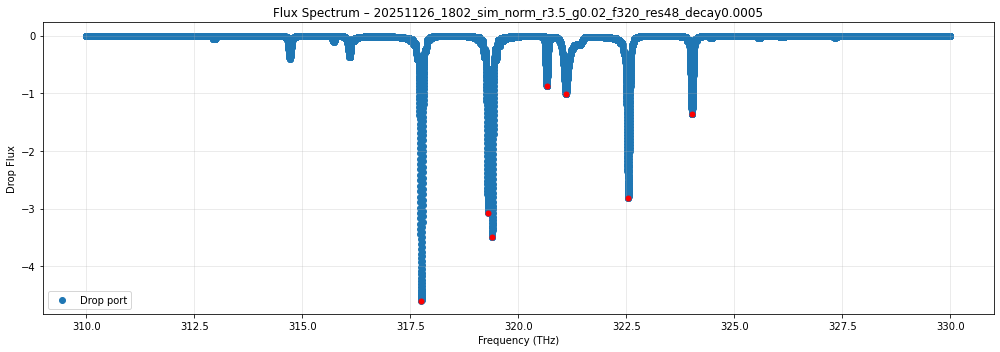


 Resonance frequencies for 20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005:
[317.7594 319.2995 319.3975 320.6585 321.1036 322.5476 324.0207]


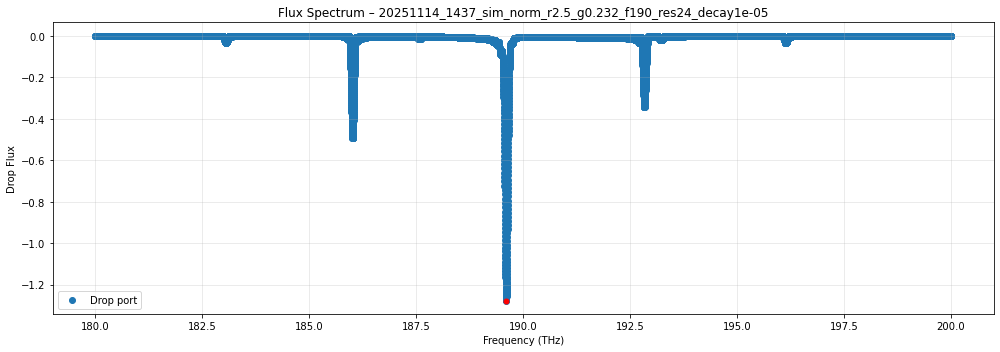


 Resonance frequencies for 20251114_1437_sim_norm_r2.5_g0.232_f190_res24_decay1e-05:
[189.6055]


In [10]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # speed of light in m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Base directory
# ---------------------------------
base_dir = "data"

# ---------------------------------
# Choose which simulation runs to plot
# ---------------------------------
selected_folders = [
    "20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005",
    "20251114_1437_sim_norm_r2.5_g0.232_f190_res24_decay1e-05"
]


# ---------------------------------
# Helper: load flux data from HDF5
# ---------------------------------
def load_flux_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq = f["frequency"][:]       # Meep units (1/µm)
        flux_bus = f["flux_bus"][:]
        flux_drop = f["flux_drop"][:]
    return freq, flux_bus, flux_drop

# ---------------------------------
# Helper: parse parameters from folder name
# ---------------------------------
def parse_params_from_name(folder_name):
    pattern = (
        r"(?P<date>\d{8})_(?P<time>\d{4})_sim_r(?P<r>[\d\.]+)_g(?P<g>[\d\.]+)"
        r"_f(?P<f>[\d\.]+)_res(?P<res>\d+)_decay(?P<decay>[\deE\-\+\.]+)"
    )
    match = re.search(pattern, folder_name)
    return match.groupdict() if match else {}

# ---------------------------------
# Collect resonance data
# ---------------------------------
resonance_summary = []

# ---------------------------------
# Main loop: process and plot each dataset
# ---------------------------------
for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    flux_file = os.path.join(run_dir, "flux_data.h5")

    if not os.path.exists(flux_file):
        print(f"No flux_data.h5 found in {run_dir}, skipping.")
        continue
    
    
    # --- Load flux data ---
    freq_meep, flux_bus, flux_drop = load_flux_data(flux_file)

    # --- Convert Meep frequency to THz ---
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # --- Normalize drop-port flux ---
    #flux_drop = flux_drop / np.max(np.abs(flux_drop))

    # --- Find resonance peaks ---
    peaks, _ = find_peaks(-flux_drop, prominence=0.5)
    res_freqs = freq_thz[peaks]

    # --- Get parameters for labeling ---
    params = parse_params_from_name(folder)
    date = params.get("date", "unknown")
    time = params.get("time", "unknown")
    r = params.get("r", "?")
    g = params.get("g", "?")
    res = params.get("res", "?")

    # --- Save for summary plot ---
    resonance_summary.append({
        "folder": folder,
        "res_freqs": res_freqs,
        "date": date,
        "time": time
    })

    # --- Plot each dataset separately ---
    plt.figure(figsize=(14,5))
    #plt.plot(freq_thz, flux_drop, lw=1.5, color="C0", label="Drop port")
    #plt.plot(freq_thz, flux_bus, lw=1.5, color="C1", label="Bus port")
    plt.scatter(res_freqs, flux_drop[peaks], color="red", s=25, zorder=5)
    plt.scatter(freq_thz, flux_drop, color="C0", label="Drop port")

    # --- Labels and title ---
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Drop Flux")
    plt.title(f"Flux Spectrum – {folder}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # --- Show or save plot ---
    plt.show()

    # --- Print resonance info ---
    print(f"\n Resonance frequencies for {folder}:")
    print(np.round(res_freqs, 4))


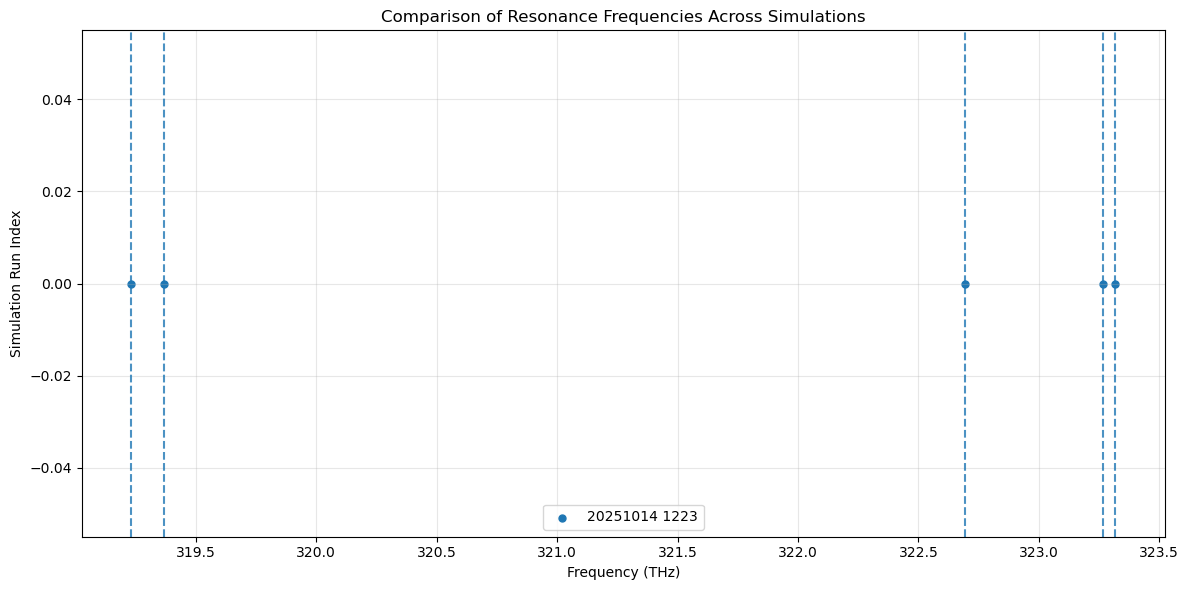

In [14]:
# ---------------------------------
# Summary: plot resonance frequencies of all runs
# ---------------------------------
plt.figure(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, entry in enumerate(resonance_summary):
    res_freqs = entry["res_freqs"]
    label = f"{entry['date']} {entry['time']}"
    for f in res_freqs:
        plt.axvline(f, color=colors[i % len(colors)], linestyle='--', alpha=0.8)
    plt.scatter(res_freqs, np.ones_like(res_freqs) * i, color=colors[i % len(colors)], s=25, label=label)

plt.xlabel("Frequency (THz)")
plt.ylabel("Simulation Run Index")
plt.title("Comparison of Resonance Frequencies Across Simulations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Normalization 

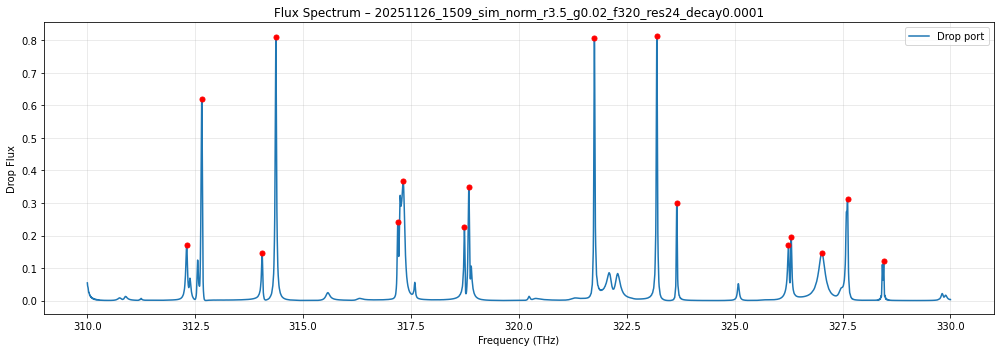


 Resonance frequencies for 20251126_1509_sim_norm_r3.5_g0.02_f320_res24_decay0.0001:
[312.3007 312.6514 314.0495 314.3675 317.1942 317.3162 318.7376 318.8396
 321.7497 323.1964 323.6585 326.2465 326.3092 327.0172 327.6146 328.4526]


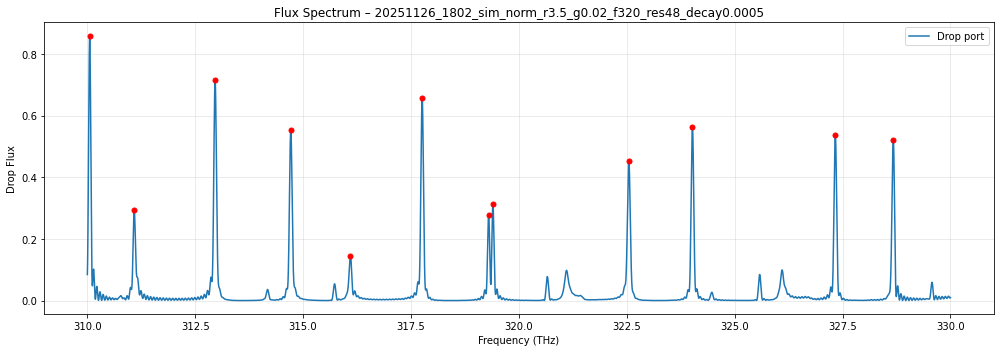


 Resonance frequencies for 20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005:
[310.054  311.0861 312.9601 314.7142 316.0963 317.7584 319.2995 319.3975
 322.5476 324.0217 327.3319 328.6759]


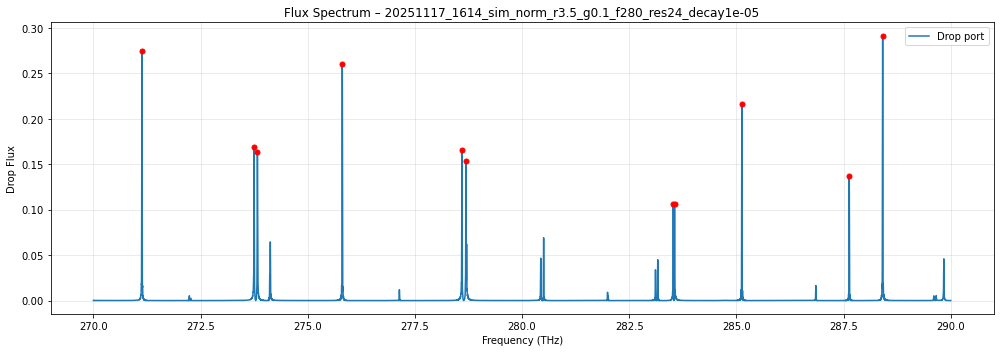


 Resonance frequencies for 20251117_1614_sim_norm_r3.5_g0.1_f280_res24_decay1e-05:
[271.1311 273.7482 273.8252 275.8053 278.5964 278.6904 283.5267 283.5567
 285.1268 287.6319 288.4119]


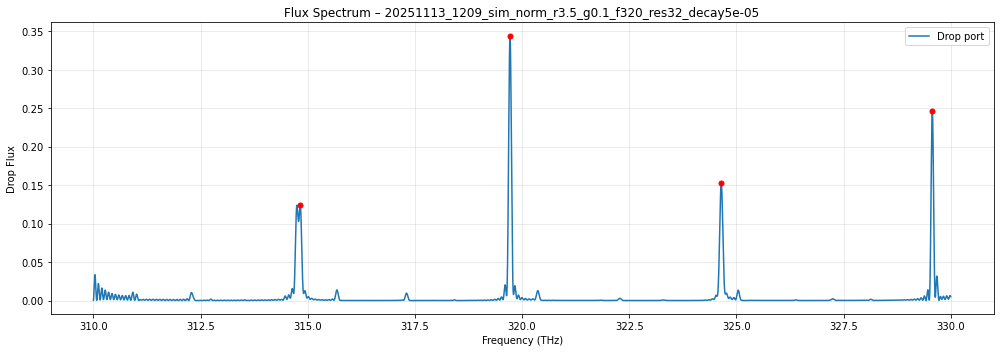


 Resonance frequencies for 20251113_1209_sim_norm_r3.5_g0.1_f320_res32_decay5e-05:
[314.8242 319.7183 324.6465 329.5707]


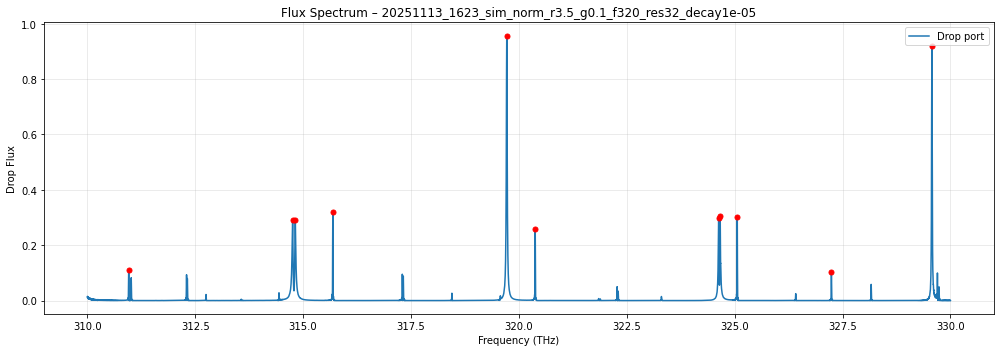


 Resonance frequencies for 20251113_1623_sim_norm_r3.5_g0.1_f320_res32_decay1e-05:
[310.958  314.7562 314.8175 315.6882 319.7183 320.3777 324.6285 324.6638
 325.0592 327.2412 329.57  ]


In [3]:
# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # speed of light in m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Base directory
# ---------------------------------
base_dir = "data"

# ---------------------------------
# Choose which simulation runs to plot
# ---------------------------------
selected_folders = [
    "20251126_1509_sim_norm_r3.5_g0.02_f320_res24_decay0.0001",
    "20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005",
    "20251117_1614_sim_norm_r3.5_g0.1_f280_res24_decay1e-05", 
    "20251113_1209_sim_norm_r3.5_g0.1_f320_res32_decay5e-05",
    "20251113_1623_sim_norm_r3.5_g0.1_f320_res32_decay1e-05"
]


# ---------------------------------
# Helper: load flux data from HDF5
# ---------------------------------
def load_flux_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq = f["frequency"][:]       # Meep units (1/µm)
        flux_bus = f["flux_bus"][:]
        flux_drop = f["flux_drop"][:]
    return freq, flux_bus, flux_drop

# ---------------------------------
# Helper: parse parameters from folder name
# ---------------------------------
def parse_params_from_name(folder_name):
    pattern = (
        r"(?P<date>\d{8})_(?P<time>\d{4})_sim_r(?P<r>[\d\.]+)_g(?P<g>[\d\.]+)"
        r"_f(?P<f>[\d\.]+)_res(?P<res>\d+)_decay(?P<decay>[\deE\-\+\.]+)"
    )
    match = re.search(pattern, folder_name)
    return match.groupdict() if match else {}

# ---------------------------------
# Collect resonance data
# ---------------------------------
resonance_summary = []

# ---------------------------------
# Main loop: process and plot each dataset
# ---------------------------------
for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    flux_file = os.path.join(run_dir, "flux_data.h5")

    if not os.path.exists(flux_file):
        print(f"No flux_data.h5 found in {run_dir}, skipping.")
        continue
    
    # --- Load flux data ---
    freq_meep, flux_bus, flux_drop = load_flux_data(flux_file)



    norm_flux_path = os.path.join(run_dir, "norm_flux.npy")
    norm_freqs_path = os.path.join(run_dir, "norm_freqs.npy")

    if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
        norm_flux = np.load(norm_flux_path)
        norm_freqs = np.load(norm_freqs_path)



        # Ensure frequency alignment (optional: interpolate if needed)
        if not np.allclose(freq_meep, norm_freqs):
            # Interpolate normalization flux to match simulation frequencies
            norm_flux = np.interp(freq_meep, norm_freqs, norm_flux)

        # Normalize drop-port flux
        flux_drop_normalized = flux_drop / norm_flux
    else:
        print(f"No normalization data found in {run_dir}, using raw flux.")
        flux_drop_normalized = flux_drop


    # --- Convert Meep frequency to THz ---
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # --- Find resonance peaks ---
    peaks, _ = find_peaks(-flux_drop_normalized, prominence=0.1)
    res_freqs = freq_thz[peaks]

    # --- Get parameters for labeling ---
    params = parse_params_from_name(folder)
    date = params.get("date", "unknown")
    time = params.get("time", "unknown")
    r = params.get("r", "?")
    g = params.get("g", "?")
    res = params.get("res", "?")

    # --- Save for summary plot ---
    resonance_summary.append({
        "folder": folder,
        "res_freqs": res_freqs,
        "date": date,
        "time": time
    })

    # --- Plot each dataset separately ---
    plt.figure(figsize=(14,5))
    plt.plot(freq_thz, np.abs(flux_drop_normalized), lw=1.5, color="C0", label="Drop port")
    #plt.plot(freq_thz, flux_drop, lw=1.5, color="C0", label="Drop port")
    #plt.plot(norm_freqs * (c0 / um_scale) / 1e12, norm_flux, lw=1.5, color="C2", label="Normalization Flux")
    #plt.plot(freq_thz, flux_bus, lw=1.5, color="C1", label="Bus port")
    plt.scatter(res_freqs, -flux_drop_normalized[peaks], color="red", s=25, zorder=5)

    # --- Labels and title ---
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Drop Flux")
    plt.title(f"Flux Spectrum – {folder}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # --- Show or save plot ---
    plt.show()

    # --- Print resonance info ---
    print(f"\n Resonance frequencies for {folder}:")
    print(np.round(res_freqs, 4))


### with harminv

No harminv_data.h5 found in data_large_sweep/20251124_1622_sim_norm_f314_res48_decay0.05_harminv_tunerFalse_tw0.15_gt0.1, skipping.


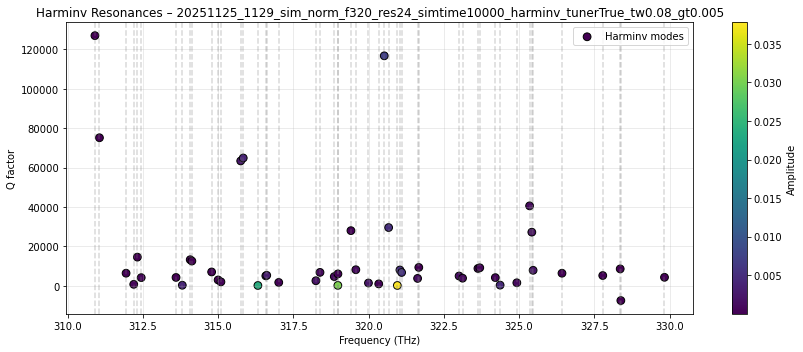


Harminv modes for 20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005:
  310.910 THz   Q = 127032.6   decay = -4.08e-06   amplitude = 1.27e-04   error = 3.08e-09+0.00e+00j
  311.060 THz   Q = 75182.3   decay = -6.90e-06   amplitude = 1.00e-04   error = 3.32e-08+0.00e+00j
  311.944 THz   Q = 6389.0   decay = -8.14e-05   amplitude = 2.28e-04   error = 5.50e-08+0.00e+00j
  312.199 THz   Q = 738.7   decay = -7.05e-04   amplitude = 6.51e-04   error = 1.10e-06+0.00e+00j
  312.319 THz   Q = 14547.9   decay = -3.58e-05   amplitude = 1.44e-04   error = 1.73e-08+0.00e+00j
  312.447 THz   Q = 4146.2   decay = -1.26e-04   amplitude = 4.67e-04   error = 7.14e-08+0.00e+00j
  313.603 THz   Q = 4242.2   decay = -1.23e-04   amplitude = 9.77e-05   error = 3.24e-07+0.00e+00j
  313.811 THz   Q = 281.9   decay = -1.86e-03   amplitude = 4.07e-03   error = 3.80e-07+0.00e+00j
  314.075 THz   Q = 13247.3   decay = -3.95e-05   amplitude = 1.25e-04   error = 3.97e-08+0.00e+00j
  314.

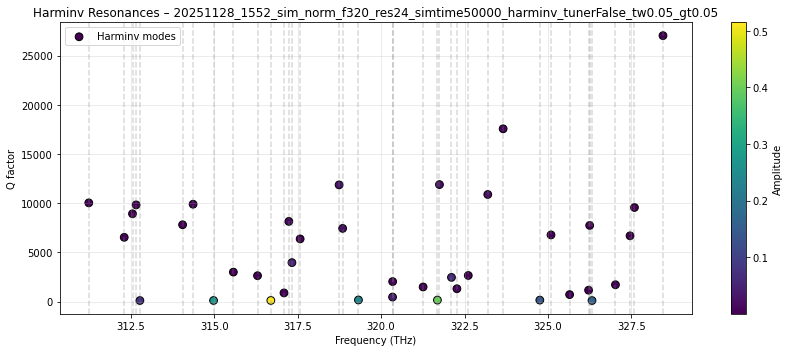


Harminv modes for 20251128_1552_sim_norm_f320_res24_simtime50000_harminv_tunerFalse_tw0.05_gt0.05:
  311.241 THz   Q = 10032.5   decay = -5.17e-05   amplitude = 4.91e-05   error = 9.60e-10+0.00e+00j
  312.303 THz   Q = 6526.7   decay = -7.98e-05   amplitude = 2.49e-03   error = 5.08e-10+0.00e+00j
  312.551 THz   Q = 8924.4   decay = -5.84e-05   amplitude = 1.91e-03   error = 5.63e-10+0.00e+00j
  312.659 THz   Q = 9827.0   decay = -5.31e-05   amplitude = 1.88e-03   error = 5.36e-10+0.00e+00j
  312.773 THz   Q = 97.9   decay = -5.33e-03   amplitude = 7.61e-02   error = 2.23e-06+0.00e+00j
  314.052 THz   Q = 7805.4   decay = -6.71e-05   amplitude = 2.72e-03   error = 8.82e-11+0.00e+00j
  314.366 THz   Q = 9894.1   decay = -5.30e-05   amplitude = 7.10e-03   error = 1.17e-12+0.00e+00j
  314.980 THz   Q = 103.5   decay = -5.08e-03   amplitude = 2.68e-01   error = 2.19e-06+0.00e+00j
  315.574 THz   Q = 2989.3   decay = -1.76e-04   amplitude = 9.41e-04   error = 2.36e-08+0.00e+00j
  316.298 T

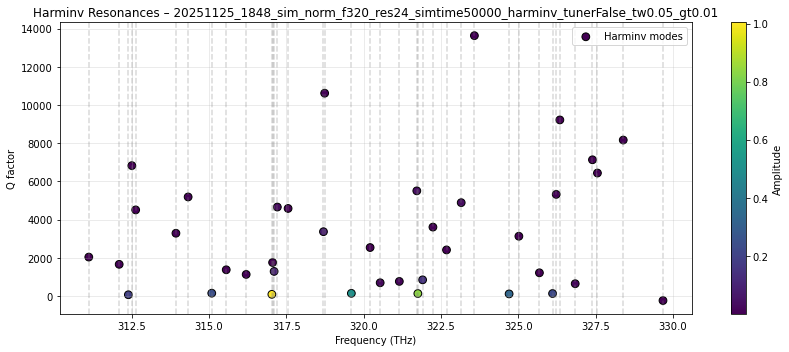


Harminv modes for 20251125_1848_sim_norm_f320_res24_simtime50000_harminv_tunerFalse_tw0.05_gt0.01:
  311.113 THz   Q = 2041.2   decay = -2.54e-04   amplitude = 2.16e-04   error = 2.67e-08+0.00e+00j
  312.095 THz   Q = 1661.9   decay = -3.13e-04   amplitude = 5.10e-03   error = 5.14e-09+0.00e+00j
  312.392 THz   Q = 70.1   decay = -7.43e-03   amplitude = 1.89e-01   error = 5.01e-06+0.00e+00j
  312.504 THz   Q = 6826.8   decay = -7.63e-05   amplitude = 1.47e-03   error = 2.96e-10+0.00e+00j
  312.628 THz   Q = 4509.7   decay = -1.16e-04   amplitude = 3.01e-03   error = 1.86e-10+0.00e+00j
  313.930 THz   Q = 3287.8   decay = -1.59e-04   amplitude = 5.32e-03   error = 2.11e-09+0.00e+00j
  314.325 THz   Q = 5187.3   decay = -1.01e-04   amplitude = 1.03e-02   error = 5.54e-10+0.00e+00j
  315.089 THz   Q = 152.0   decay = -3.46e-03   amplitude = 2.42e-01   error = 4.88e-07+0.00e+00j
  315.557 THz   Q = 1376.9   decay = -3.82e-04   amplitude = 2.21e-03   error = 2.37e-09+0.00e+00j
  316.201 TH

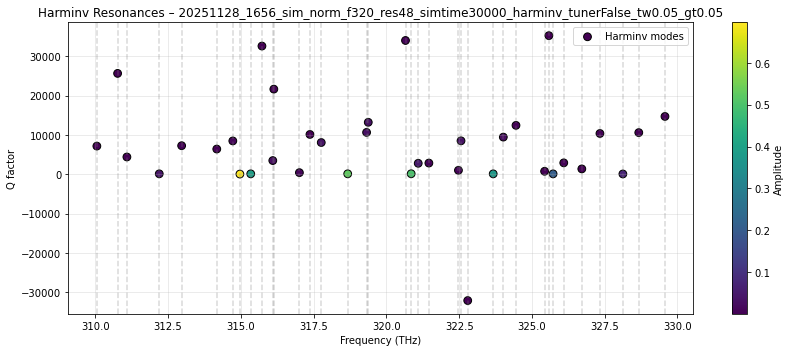


Harminv modes for 20251128_1656_sim_norm_f320_res48_simtime30000_harminv_tunerFalse_tw0.05_gt0.05:
  310.054 THz   Q = 7159.9   decay = -7.22e-05   amplitude = 4.37e-04   error = 2.03e-09+0.00e+00j
  310.766 THz   Q = 25632.3   decay = -2.02e-05   amplitude = 2.08e-05   error = 5.42e-10+0.00e+00j
  311.085 THz   Q = 4394.4   decay = -1.18e-04   amplitude = 1.08e-03   error = 8.87e-11+0.00e+00j
  312.197 THz   Q = 115.2   decay = -4.52e-03   amplitude = 3.84e-02   error = 5.47e-07+0.00e+00j
  312.966 THz   Q = 7261.2   decay = -7.19e-05   amplitude = 4.40e-03   error = 5.18e-11+0.00e+00j
  314.173 THz   Q = 6409.1   decay = -8.18e-05   amplitude = 2.20e-03   error = 3.78e-11+0.00e+00j
  314.724 THz   Q = 8472.9   decay = -6.20e-05   amplitude = 1.28e-02   error = 2.85e-11+0.00e+00j
  314.967 THz   Q = 54.4   decay = -9.65e-03   amplitude = 6.97e-01   error = 3.20e-06+0.00e+00j
  315.340 THz   Q = 111.5   decay = -4.72e-03   amplitude = 3.92e-01   error = 3.69e-07+0.00e+00j
  315.725 TH

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Base directory
# ---------------------------------
base_dir = "data_large_sweep"

# ---------------------------------
# Choose which simulation runs to plot
# ---------------------------------
selected_folders = [
    "20251124_1622_sim_norm_f314_res48_decay0.05_harminv_tunerFalse_tw0.15_gt0.1",
    "20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005",
    "20251128_1552_sim_norm_f320_res24_simtime50000_harminv_tunerFalse_tw0.05_gt0.05",
    "20251125_1848_sim_norm_f320_res24_simtime50000_harminv_tunerFalse_tw0.05_gt0.01",
    "20251128_1656_sim_norm_f320_res48_simtime30000_harminv_tunerFalse_tw0.05_gt0.05"
]

# ---------------------------------
# Helper: load harminv data from HDF5
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
        amplitude = f["amplitude"][:] if "amplitude" in f else np.full_like(Q, np.nan)
        error = f["error"][:] if "error" in f else np.full_like(Q, np.nan)
        
    return freq_meep, Q, decay, amplitude, error

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # speed of light in m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Main loop: process and plot each dataset
# ---------------------------------
for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    harminv_file = os.path.join(run_dir, "harminv_data.h5")

    if not os.path.exists(harminv_file):
        print(f"No harminv_data.h5 found in {run_dir}, skipping.")
        continue

    # --- Load harminv data ---
    freq_meep, Q, decay, amplitude, error = load_harminv_data(harminv_file)
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    # Use amplitude for color only if it is not nan, otherwise use a single color
    if np.all(np.isnan(amplitude)):
        plt.scatter(freq_thz, Q, color="C0", s=60, edgecolor="k", label="Harminv modes")
    else:
        plt.scatter(freq_thz, Q, c=amplitude, cmap="viridis", s=60, edgecolor="k", label="Harminv modes")
        plt.colorbar(label="Amplitude")
    # Overlay frequency markers for clarity
    for f in freq_thz:
        plt.axvline(f, color="gray", linestyle="--", alpha=0.3)
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Q factor")
    plt.title(f"Harminv Resonances – {folder}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()

    # --- Print resonance info ---
    print(f"\nHarminv modes for {folder}:")
    for f, q, d, a, e in zip(freq_thz, Q, decay, amplitude, error):
        print(f"  {f:.3f} THz   Q = {q:.1f}   decay = {d:.2e}   amplitude = {a:.2e}   error = {e:.2e}")

20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001: Selected peak freq = 314.176 THz, Q = 72573.0, tuner_width = 0.0
20251125_1112_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.005: No peak found in specified range. tuner_width = 0.05
20251125_1118_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.005: Selected peak freq = 311.555 THz, Q = 78417.0, tuner_width = 0.06
20251125_1124_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.005: Selected peak freq = 311.126 THz, Q = 50035.9, tuner_width = 0.07
20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005: Selected peak freq = 311.060 THz, Q = 75182.3, tuner_width = 0.08
20251125_1132_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.005: Selected peak freq = 310.805 THz, Q = 53590.5, tuner_width = 0.09
20251125_1135_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.005: Selected peak freq = 310.582 THz, Q = 84405.8, tuner_width = 0.1


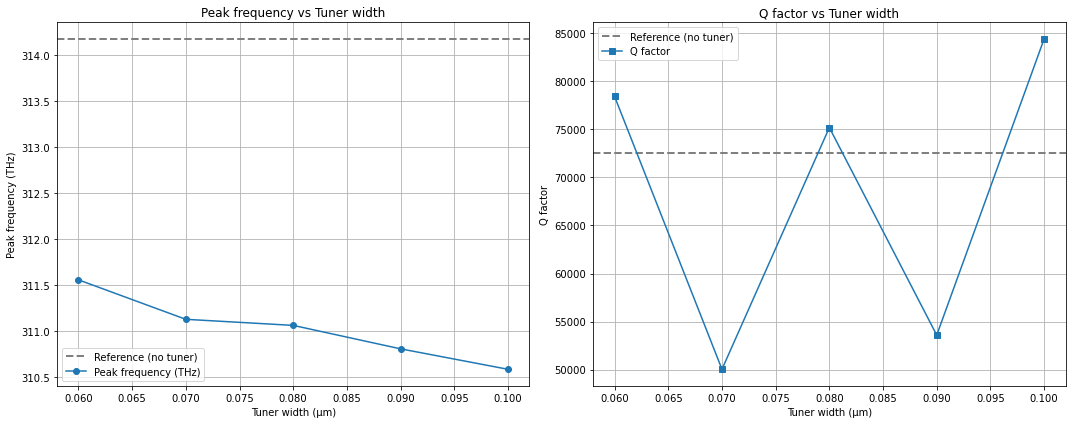

In [27]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Helper: load harminv data from HDF5
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
        amplitude = f["amplitude"][:] if "amplitude" in f else np.full_like(Q, np.nan)
        error = f["error"][:] if "error" in f else np.full_like(Q, np.nan)
    return freq_meep, Q, decay, amplitude, error

# ---------------------------------
# Helper: extract tuner_width from params.txt
# ---------------------------------
def extract_tuner_width(params_path):
    tuner_width = None
    if not os.path.exists(params_path):
        return np.nan
    with open(params_path, "r") as f:
        for line in f:
            match = re.match(r"\s*tuner_width\s*=\s*([0-9.eE+-]+)", line)
            if match:
                tuner_width = float(match.group(1))
                break
    return tuner_width if tuner_width is not None else np.nan

# ---------------------------------
# Main: compare peak position and Q factor across folders
# ---------------------------------
base_dir = "data_large_sweep"
selected_folders = [
    '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
    '20251125_1112_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.005',
    '20251125_1118_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.005',
    '20251125_1124_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.005',
    '20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005',
    '20251125_1132_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.005',
    '20251125_1135_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.005'
]

# Specify frequency and Q factor ranges
freq_min = 310  # THz
freq_max = 315    # THz
Q_min = 50000
Q_max = 100000

peak_freqs = []
peak_Qs = []
tuner_widths = []

for i, folder in enumerate(selected_folders):
    run_dir = os.path.join(base_dir, folder)
    harminv_file = os.path.join(run_dir, "harminv_data.h5")
    params_file = os.path.join(run_dir, "params.txt")
    if i == 0:
        tuner_width = 0.0  # Manually set reference folder to tuner_width = 0
    else:
        tuner_width = extract_tuner_width(params_file)

    if not os.path.exists(harminv_file):
        print(f"No harminv_data.h5 found in {run_dir}, skipping.")
        peak_freqs.append(np.nan)
        peak_Qs.append(np.nan)
        tuner_widths.append(tuner_width)
        continue

    freq_meep, Q, decay, amplitude, error = load_harminv_data(harminv_file)
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # Filter modes by frequency and Q factor range
    mask = (freq_thz >= freq_min) & (freq_thz <= freq_max) & (Q >= Q_min) & (Q <= Q_max)
    if np.any(mask):
        idx = np.argmax(Q[mask])  # pick highest Q in range
        freq_sel = freq_thz[mask][idx]
        Q_sel = Q[mask][idx]
        peak_freqs.append(freq_sel)
        peak_Qs.append(Q_sel)
        tuner_widths.append(tuner_width)
        print(f"{folder}: Selected peak freq = {freq_sel:.3f} THz, Q = {Q_sel:.1f}, tuner_width = {tuner_width}")
    else:
        peak_freqs.append(np.nan)
        peak_Qs.append(np.nan)
        tuner_widths.append(tuner_width)
        print(f"{folder}: No peak found in specified range. tuner_width = {tuner_width}")

# ...existing code...
plt.figure(figsize=(15, 6))

# --- Peak frequency plot ---
plt.subplot(1, 2, 1)
# Plot reference as horizontal line (first entry)
ref_freq = peak_freqs[0]
plt.axhline(ref_freq, color='gray', linestyle='--', linewidth=2, label='Reference (no tuner)')
# Plot remaining points (exclude first)
plt.plot(tuner_widths[1:], peak_freqs[1:], 'o-', label="Peak frequency (THz)")
plt.xlabel("Tuner width (µm)")
plt.ylabel("Peak frequency (THz)")
plt.title("Peak frequency vs Tuner width")
plt.grid(True)
plt.legend()

# --- Q factor plot ---
plt.subplot(1, 2, 2)
ref_Q = peak_Qs[0]
plt.axhline(ref_Q, color='gray', linestyle='--', linewidth=2, label='Reference (no tuner)')
plt.plot(tuner_widths[1:], peak_Qs[1:], 's-', color='tab:blue', label="Q factor")
plt.xlabel("Tuner width (µm)")
plt.ylabel("Q factor")
plt.title("Q factor vs Tuner width")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

[Dataset 1] 20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001: freq = 314.176 THz, Q = 72573.0, tuner_width = 0.0
[Dataset 1] 20251125_1112_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.005: freq = 313.104 THz, Q = 20936.3, tuner_width = 0.05
[Dataset 1] 20251125_1118_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.005: freq = 314.567 THz, Q = 25670.3, tuner_width = 0.06
[Dataset 1] 20251125_1124_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.005: freq = 314.342 THz, Q = 11312.0, tuner_width = 0.07
[Dataset 1] 20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005: freq = 314.075 THz, Q = 13247.3, tuner_width = 0.08
[Dataset 1] 20251125_1132_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.005: freq = 313.810 THz, Q = 12079.7, tuner_width = 0.09
[Dataset 1] 20251125_1135_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.005: No peak found in range. tuner_width = 0.1
[Dataset 2] 20251119_1

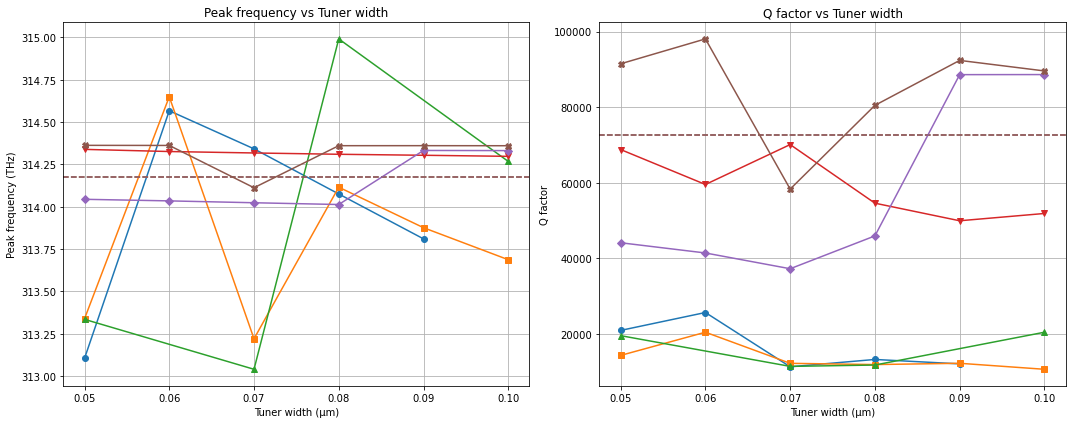

In [43]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Helper: load harminv data from HDF5
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
        amplitude = f["amplitude"][:] if "amplitude" in f else np.full_like(Q, np.nan)
        error = f["error"][:] if "error" in f else np.full_like(Q, np.nan)
    return freq_meep, Q, decay, amplitude, error

# ---------------------------------
# Helper: extract tuner_width from params.txt
# ---------------------------------
def extract_tuner_width(params_path):
    tuner_width = None
    if not os.path.exists(params_path):
        return np.nan
    with open(params_path, "r") as f:
        for line in f:
            match = re.match(r"\s*tuner_width\s*=\s*([0-9.eE+-]+)", line)
            if match:
                tuner_width = float(match.group(1))
                break
    return tuner_width if tuner_width is not None else np.nan

# ---------------------------------
# Helper: process a single dataset
# ---------------------------------
def process_dataset(base_dir, folder_list, label, freq_min, freq_max, Q_min, Q_max, 
                    reference_tuner_width=0.0):
    """
    Process a list of folders and extract peak frequencies and Q factors.
    
    Parameters:
    -----------
    base_dir : str
        Base directory containing data folders
    folder_list : list of str
        List of folder names to process
    label : str
        Label for this dataset
    freq_min, freq_max : float
        Frequency range in THz
    Q_min, Q_max : float
        Q factor range
    reference_tuner_width : float
        Tuner width to assign to first folder (default 0.0)
    
    Returns:
    --------
    dict with keys: 'tuner_widths', 'peak_freqs', 'peak_Qs', 'label'
    """
    peak_freqs = []
    peak_Qs = []
    tuner_widths = []
    
    for i, folder in enumerate(folder_list):
        run_dir = os.path.join(base_dir, folder)
        harminv_file = os.path.join(run_dir, "harminv_data.h5")
        params_file = os.path.join(run_dir, "params.txt")
        
        # Set tuner width
        if i == 0:
            tuner_width = reference_tuner_width
        else:
            tuner_width = extract_tuner_width(params_file)
        
        if not os.path.exists(harminv_file):
            print(f"[{label}] No harminv_data.h5 found in {run_dir}, skipping.")
            peak_freqs.append(np.nan)
            peak_Qs.append(np.nan)
            tuner_widths.append(tuner_width)
            continue
        
        freq_meep, Q, decay, amplitude, error = load_harminv_data(harminv_file)
        freq_thz = freq_meep * (c0 / um_scale) / 1e12
        
        # Filter modes by frequency and Q factor range
        mask = (freq_thz >= freq_min) & (freq_thz <= freq_max) & (Q >= Q_min) & (Q <= Q_max)
        if np.any(mask):
            idx = np.argmax(Q[mask])  # pick highest Q in range
            freq_sel = freq_thz[mask][idx]
            Q_sel = Q[mask][idx]
            peak_freqs.append(freq_sel)
            peak_Qs.append(Q_sel)
            tuner_widths.append(tuner_width)
            print(f"[{label}] {folder}: freq = {freq_sel:.3f} THz, Q = {Q_sel:.1f}, tuner_width = {tuner_width}")
        else:
            peak_freqs.append(np.nan)
            peak_Qs.append(np.nan)
            tuner_widths.append(tuner_width)
            print(f"[{label}] {folder}: No peak found in range. tuner_width = {tuner_width}")
    
    return {
        'tuner_widths': np.array(tuner_widths),
        'peak_freqs': np.array(peak_freqs),
        'peak_Qs': np.array(peak_Qs),
        'label': label
    }

# ---------------------------------
# Main: Define multiple datasets
# ---------------------------------
base_dir = "data_large_sweep"

# Define multiple datasets as a list of dictionaries
# ...existing code...
datasets = [
    {
        'label': 'Dataset 1',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1112_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.005',
            '20251125_1118_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.005',
            '20251125_1124_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.005',
            '20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005',
            '20251125_1132_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.005',
            '20251125_1135_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.005'
        ],
        'reference_tuner_width': 0.0,
        'color': 'tab:blue',
        'marker': 'o'
    },
    {
        'label': 'Dataset 2',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1144_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.01',
            '20251125_1147_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.01',
            '20251125_1150_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.01',
            '20251125_1154_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.01',
            '20251125_1158_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.01',
            '20251125_1203_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.01'
        ],
        'reference_tuner_width': 0.0,
        'color': 'tab:orange',
        'marker': 's'
    },
    {
        'label': 'Dataset 3',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1208_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.02',
            '20251125_1211_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.02',
            '20251125_1215_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.02',
            '20251125_1217_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.02',
            '20251125_1220_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.02',
            '20251125_1222_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.02'
        ],
        'reference_tuner_width': 0.05,
        'color': 'tab:green',
        'marker': '^'
    },
    {
        'label': 'Dataset 4',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1225_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.03',
            '20251125_1227_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.03',
            '20251125_1230_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.03',
            '20251125_1232_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.03',
            '20251125_1235_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.03',
            '20251125_1237_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.03'
        ],
        'reference_tuner_width': 0.05,
        'color': 'tab:red',
        'marker': 'v'
    },
    {
        'label': 'Dataset 5',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1240_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.07',
            '20251125_1242_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.07',
            '20251125_1245_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.07',
            '20251125_1247_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.07',
            '20251125_1250_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.07',
            '20251125_1252_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.07'
        ],
        'reference_tuner_width': 0.05,
        'color': 'tab:purple',
        'marker': 'D'
    },
    {
        'label': 'Dataset 6',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1255_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.1',
            '20251125_1258_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.1',
            '20251125_1300_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.1',
            '20251125_1302_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.1',
            '20251125_1305_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.1',
            '20251125_1307_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.1'
        ],
        'reference_tuner_width': 0.05,
        'color': 'tab:brown',
        'marker': 'X'
    }
]
# ...existing code...

# Specify frequency and Q factor ranges
freq_min = 313  # THz
freq_max = 315  # THz
Q_min = 10000
Q_max = 100000

# Process all datasets
results = []
for dataset in datasets:
    result = process_dataset(
        base_dir=base_dir,
        folder_list=dataset['folders'],
        label=dataset['label'],
        freq_min=freq_min,
        freq_max=freq_max,
        Q_min=Q_min,
        Q_max=Q_max,
        reference_tuner_width=dataset.get('reference_tuner_width', 0.0)
    )
    result['color'] = dataset.get('color', None)
    result['marker'] = dataset.get('marker', 'o')
    results.append(result)

# ---------------------------------
# Plotting: All datasets on same plots
# ---------------------------------
plt.figure(figsize=(15, 6))

# --- Peak frequency plot ---
plt.subplot(1, 2, 1)
for result in results:
    # Plot reference as horizontal line (first entry)
    ref_freq = result['peak_freqs'][0]
    plt.axhline(ref_freq, color=result['color'], linestyle='--', linewidth=1.5, 
                alpha=0.5)
    
    # Plot remaining points (exclude first)
    valid_mask = ~np.isnan(result['peak_freqs'][1:])
    plt.plot(result['tuner_widths'][1:][valid_mask], 
             result['peak_freqs'][1:][valid_mask], 
             marker=result['marker'], 
             linestyle='-',
             color=result['color'],
             label=result['label'])

plt.xlabel("Tuner width (µm)")
plt.ylabel("Peak frequency (THz)")
plt.title("Peak frequency vs Tuner width")
plt.grid(True)

# --- Q factor plot ---
plt.subplot(1, 2, 2)
for result in results:
    ref_Q = result['peak_Qs'][0]
    plt.axhline(ref_Q, color=result['color'], linestyle='--', linewidth=1.5,
                alpha=0.5)
    
    valid_mask = ~np.isnan(result['peak_Qs'][1:])
    plt.plot(result['tuner_widths'][1:][valid_mask], 
             result['peak_Qs'][1:][valid_mask], 
             marker=result['marker'],
             linestyle='-',
             color=result['color'],
             label=result['label'])

plt.xlabel("Tuner width (µm)")
plt.ylabel("Q factor")
plt.title("Q factor vs Tuner width")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Helper: load harminv data from HDF5
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
        amplitude = f["amplitude"][:] if "amplitude" in f else np.full_like(Q, np.nan)
        error = f["error"][:] if "error" in f else np.full_like(Q, np.nan)
    return freq_meep, Q, decay, amplitude, error

# ---------------------------------
# Helper: extract tuner_width from params.txt
# ---------------------------------
def extract_tuner_width(params_path):
    tuner_width = None
    if not os.path.exists(params_path):
        return np.nan
    with open(params_path, "r") as f:
        for line in f:
            match = re.match(r"\s*tuner_width\s*=\s*([0-9.eE+-]+)", line)
            if match:
                tuner_width = float(match.group(1))
                break
    return tuner_width if tuner_width is not None else np.nan

# ---------------------------------
# Helper: process a single dataset
# ---------------------------------
def process_dataset(base_dir, folder_list, label, freq_min, freq_max, Q_min, Q_max, 
                    reference_tuner_width=0.0):
    """
    Process a list of folders and extract peak frequencies and Q factors.
    
    Parameters:
    -----------
    base_dir : str
        Base directory containing data folders
    folder_list : list of str
        List of folder names to process
    label : str
        Label for this dataset
    freq_min, freq_max : float
        Frequency range in THz
    Q_min, Q_max : float
        Q factor range
    reference_tuner_width : float
        Tuner width to assign to first folder (default 0.0)
    
    Returns:
    --------
    dict with keys: 'tuner_widths', 'peak_freqs', 'peak_Qs', 'label'
    """
    peak_freqs = []
    peak_Qs = []
    tuner_widths = []
    
    for i, folder in enumerate(folder_list):
        run_dir = os.path.join(base_dir, folder)
        harminv_file = os.path.join(run_dir, "harminv_data.h5")
        params_file = os.path.join(run_dir, "params.txt")
        
        # Set tuner width
        if i == 0:
            tuner_width = reference_tuner_width
        else:
            tuner_width = extract_tuner_width(params_file)
        
        if not os.path.exists(harminv_file):
            print(f"[{label}] No harminv_data.h5 found in {run_dir}, skipping.")
            peak_freqs.append(np.nan)
            peak_Qs.append(np.nan)
            tuner_widths.append(tuner_width)
            continue
        
        freq_meep, Q, decay, amplitude, error = load_harminv_data(harminv_file)
        freq_thz = freq_meep * (c0 / um_scale) / 1e12
        
        # Filter modes by frequency and Q factor range
        mask = (freq_thz >= freq_min) & (freq_thz <= freq_max) & (Q >= Q_min) & (Q <= Q_max)
        if np.any(mask):
            idx = np.argmax(Q[mask])  # pick highest Q in range
            freq_sel = freq_thz[mask][idx]
            Q_sel = Q[mask][idx]
            peak_freqs.append(freq_sel)
            peak_Qs.append(Q_sel)
            tuner_widths.append(tuner_width)
            print(f"[{label}] {folder}: freq = {freq_sel:.3f} THz, Q = {Q_sel:.1f}, tuner_width = {tuner_width}")
        else:
            peak_freqs.append(np.nan)
            peak_Qs.append(np.nan)
            tuner_widths.append(tuner_width)
            print(f"[{label}] {folder}: No peak found in range. tuner_width = {tuner_width}")
    
    return {
        'tuner_widths': np.array(tuner_widths),
        'peak_freqs': np.array(peak_freqs),
        'peak_Qs': np.array(peak_Qs),
        'label': label
    }

# ---------------------------------
# Main: Define multiple datasets
# ---------------------------------
base_dir = "data_large_sweep"

# Define multiple datasets as a list of dictionaries
datasets = [
    {
        'label': 'Dataset 1',
        'folders': [
            '20251119_1229_sim_norm_r3.5_g0.1_f320_res24_decay0.001',
            '20251125_1112_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.05_gt0.005',
            '20251125_1118_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.06_gt0.005',
            '20251125_1124_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.07_gt0.005',
            '20251125_1129_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.08_gt0.005',
            '20251125_1132_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.09_gt0.005',
            '20251125_1135_sim_norm_f320_res24_simtime10000_harminv_tunerTrue_tw0.1_gt0.005'
        ],
        'reference_tuner_width': 0.0,
        'color': 'tab:blue',
        'marker': 'o'
    },
    # Add more datasets here as needed:
    # {
    #     'label': 'Dataset 2',
    #     'folders': ['folder1', 'folder2', ...],
    #     'reference_tuner_width': 0.0,
    #     'color': 'tab:orange',
    #     'marker': 's'
    # },
]

# Specify frequency and Q factor ranges
freq_min = 310  # THz
freq_max = 315  # THz
Q_min = 50000
Q_max = 100000

# Process all datasets
results = []
for dataset in datasets:
    result = process_dataset(
        base_dir=base_dir,
        folder_list=dataset['folders'],
        label=dataset['label'],
        freq_min=freq_min,
        freq_max=freq_max,
        Q_min=Q_min,
        Q_max=Q_max,
        reference_tuner_width=dataset.get('reference_tuner_width', 0.0)
    )
    result['color'] = dataset.get('color', None)
    result['marker'] = dataset.get('marker', 'o')
    results.append(result)

# ---------------------------------
# Plotting: All datasets on same plots
# ---------------------------------
plt.figure(figsize=(15, 6))

# --- Peak frequency plot ---
plt.subplot(1, 2, 1)
for result in results:
    # Plot reference as horizontal line (first entry)
    ref_freq = result['peak_freqs'][0]
    plt.axhline(ref_freq, color=result['color'], linestyle='--', linewidth=1.5, 
                alpha=0.5, label=f"{result['label']} Reference")
    
    # Plot remaining points (exclude first)
    valid_mask = ~np.isnan(result['peak_freqs'][1:])
    plt.plot(result['tuner_widths'][1:][valid_mask], 
             result['peak_freqs'][1:][valid_mask], 
             marker=result['marker'], 
             linestyle='-',
             color=result['color'],
             label=result['label'])

plt.xlabel("Tuner width (µm)")
plt.ylabel("Peak frequency (THz)")
plt.title("Peak frequency vs Tuner width")
plt.grid(True)
plt.legend()

# --- Q factor plot ---
plt.subplot(1, 2, 2)
for result in results:
    ref_Q = result['peak_Qs'][0]
    plt.axhline(ref_Q, color=result['color'], linestyle='--', linewidth=1.5,
                alpha=0.5, label=f"{result['label']} Reference")
    
    valid_mask = ~np.isnan(result['peak_Qs'][1:])
    plt.plot(result['tuner_widths'][1:][valid_mask], 
             result['peak_Qs'][1:][valid_mask], 
             marker=result['marker'],
             linestyle='-',
             color=result['color'],
             label=result['label'])

plt.xlabel("Tuner width (µm)")
plt.ylabel("Q factor")
plt.title("Q factor vs Tuner width")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

20251120_1712_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.001: Selected peak freq = 318.672 THz, Q = 13893.9, tuner_gap = 0.001
20251120_1714_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.005: Selected peak freq = 318.010 THz, Q = 11687.8, tuner_gap = 0.005
20251120_1903_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.03: Selected peak freq = 318.450 THz, Q = 18163.1, tuner_gap = 0.03
20251120_1935_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.05: Selected peak freq = 318.215 THz, Q = 65382.0, tuner_gap = 0.05
20251120_2016_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.08: Selected peak freq = 318.367 THz, Q = 262370.0, tuner_gap = 0.08
20251120_2051_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.1: No peak found in specified range. tuner_gap = 0.1


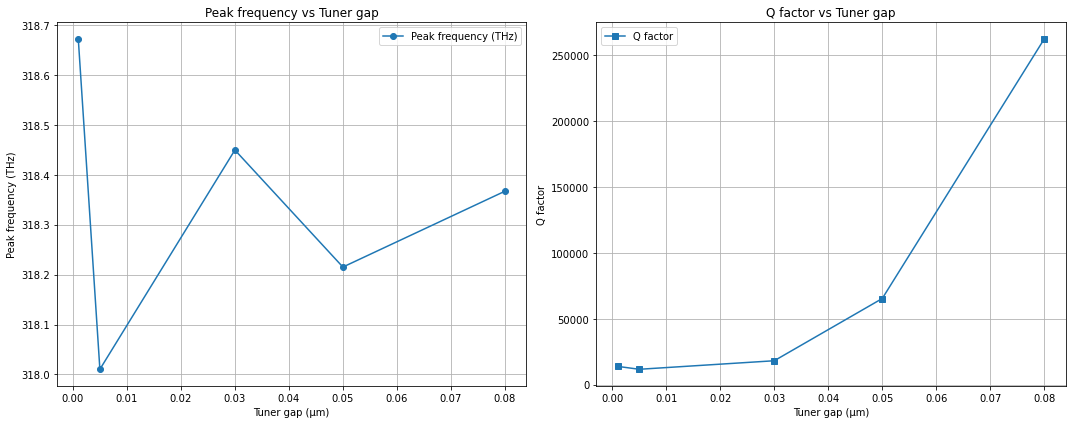

In [88]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Physical constants
# ---------------------------------
c0 = 299792458  # m/s
um_scale = 1e-6  # micrometers to meters

# ---------------------------------
# Helper: load harminv data from HDF5
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
        amplitude = f["amplitude"][:] if "amplitude" in f else np.full_like(Q, np.nan)
        error = f["error"][:] if "error" in f else np.full_like(Q, np.nan)
    return freq_meep, Q, decay, amplitude, error

# ---------------------------------
# Helper: extract tuner_gap from params.txt
# ---------------------------------
def extract_tuner_gap(params_path):
    tuner_gap = None
    if not os.path.exists(params_path):
        return np.nan
    with open(params_path, "r") as f:
        for line in f:
            match = re.match(r"\s*tuner_gap\s*=\s*([0-9.eE+-]+)", line)
            if match:
                tuner_gap = float(match.group(1))
                break
    return tuner_gap if tuner_gap is not None else np.nan

# ---------------------------------
# Main: compare peak position and Q factor across folders
# ---------------------------------
base_dir = "data"
selected_folders = [
    "20251120_1712_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.001",
    "20251120_1714_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.005",
    "20251120_1903_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.03",
    "20251120_1935_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.05",
    "20251120_2016_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.08",
    "20251120_2051_sim_norm_f320_res32_decay0.005_harminv_tunerTrue_tw0.1_gt0.1"
]

# Specify frequency and Q factor ranges

Q_min = -10000
Q_max = 300000

peak_freqs = []
peak_Qs = []
tuner_gaps = []

for i, folder in enumerate(selected_folders):

    freq_min = 318   # THz
    freq_max = 318.8    # THz

    run_dir = os.path.join(base_dir, folder)
    harminv_file = os.path.join(run_dir, "harminv_data.h5")
    params_file = os.path.join(run_dir, "params.txt")
    tuner_gap = extract_tuner_gap(params_file)

    if not os.path.exists(harminv_file):
        print(f"No harminv_data.h5 found in {run_dir}, skipping.")
        peak_freqs.append(np.nan)
        peak_Qs.append(np.nan)
        tuner_gaps.append(tuner_gap)
        continue

    freq_meep, Q, decay, amplitude, error = load_harminv_data(harminv_file)
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # Filter modes by frequency and Q factor range
    mask = (freq_thz >= freq_min) & (freq_thz <= freq_max) & (Q >= Q_min) & (Q <= Q_max)
    if np.any(mask):
        idx = np.argmax(Q[mask])  # pick highest Q in range
        freq_sel = freq_thz[mask][idx]
        Q_sel = Q[mask][idx]
        peak_freqs.append(freq_sel)
        peak_Qs.append(Q_sel)
        tuner_gaps.append(tuner_gap)
        print(f"{folder}: Selected peak freq = {freq_sel:.3f} THz, Q = {Q_sel:.1f}, tuner_gap = {tuner_gap}")
    else:
        peak_freqs.append(np.nan)
        peak_Qs.append(np.nan)
        tuner_gaps.append(tuner_gap)
        print(f"{folder}: No peak found in specified range. tuner_gap = {tuner_gap}")

# --- Plot comparison ---
plt.figure(figsize=(15, 6))

# Plot peak frequency vs tuner gap
plt.subplot(1, 2, 1)
plt.plot(tuner_gaps, peak_freqs, 'o-', label="Peak frequency (THz)")
plt.xlabel("Tuner gap (µm)")
plt.ylabel("Peak frequency (THz)")
plt.title("Peak frequency vs Tuner gap")
plt.grid(True)
plt.legend()

# Plot Q factor vs tuner gap
plt.subplot(1, 2, 2)
plt.plot(tuner_gaps, peak_Qs, 's-', color='tab:blue', label="Q factor")
plt.xlabel("Tuner gap (µm)")
plt.ylabel("Q factor")
plt.title("Q factor vs Tuner gap")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

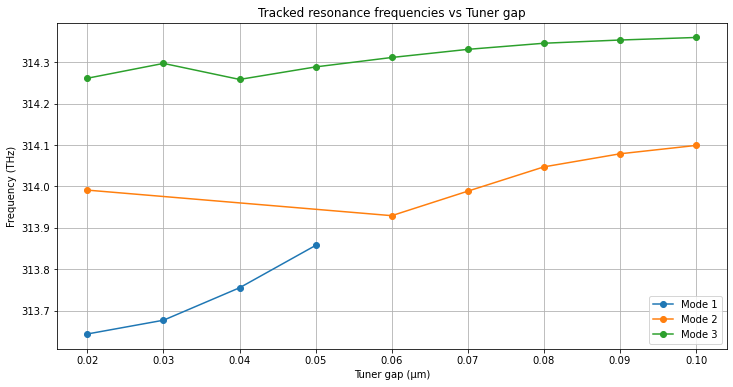

In [76]:
from scipy.optimize import linear_sum_assignment

base_dir = "data"
selected_folders = [
    "20251120_1446_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.02",
    "20251120_1457_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.03",
    "20251120_1505_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.04",
    "20251120_1512_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.05",
    "20251120_1522_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.06",
    "20251120_1533_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.07",
    "20251120_1549_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.08",
    "20251120_1602_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.09",
    "20251120_1618_sim_norm_f320_res24_decay0.005_harminv_tunerTrue_tw0.1_gt0.1"
]


freq_min = 313  # THz
freq_max = 315  # THz


def track_peaks_across_sweep(all_freqs, all_Qs, freq_tolerance):
    """
    Track multiple peaks across parameter sweep.
    Returns dict mapping peak_id -> list of (freq, Q, index) tuples
    """
    n_sweeps = len(all_freqs)
    
    # Start with reference (first sweep)
    tracks = {i: [(all_freqs[0][i], all_Qs[0][i], 0)] 
              for i in range(len(all_freqs[0]))}
    next_track_id = len(all_freqs[0])
    
    # Match peaks in subsequent sweeps
    for sweep_idx in range(1, n_sweeps):
        current_freqs = all_freqs[sweep_idx]
        current_Qs = all_Qs[sweep_idx]
        
        # Previous sweep's last frequencies
        prev_freqs = [tracks[tid][-1][0] for tid in tracks]
        
        # Build cost matrix (frequency difference)
        n_prev = len(prev_freqs)
        n_curr = len(current_freqs)
        cost_matrix = np.zeros((n_prev, n_curr))
        
        for i, pf in enumerate(prev_freqs):
            for j, cf in enumerate(current_freqs):
                cost_matrix[i, j] = abs(pf - cf)
        
        # Solve assignment problem
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # Update tracks
        used_current = set()
        for prev_idx, curr_idx in zip(row_ind, col_ind):
            if cost_matrix[prev_idx, curr_idx] < freq_tolerance:
                track_id = list(tracks.keys())[prev_idx]
                tracks[track_id].append((current_freqs[curr_idx], 
                                        current_Qs[curr_idx], 
                                        sweep_idx))
                used_current.add(curr_idx)
        
        # Create new tracks for unmatched peaks
        for j in range(n_curr):
            if j not in used_current:
                tracks[next_track_id] = [(current_freqs[j], current_Qs[j], sweep_idx)]
                next_track_id += 1
    
    return tracks

# Usage:
all_freqs = []
all_Qs = []
all_gaps = []

for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    harminv_file = os.path.join(run_dir, "harminv_data.h5")
    
    freq_meep, Q, _, _, _ = load_harminv_data(harminv_file)
    freq_thz = freq_meep * (c0 / um_scale) / 1e12
    
    # Filter by range
    mask = (freq_thz >= freq_min) & (freq_thz <= freq_max) & (Q >= Q_min) & (Q <= Q_max)
    all_freqs.append(freq_thz[mask])
    all_Qs.append(Q[mask])
    
    gap = extract_tuner_gap(os.path.join(run_dir, "params.txt"))
    all_gaps.append(gap if gap is not None else 0.0)

# Track peaks
tracks = track_peaks_across_sweep(all_freqs, all_Qs, freq_tolerance=0.5)

# Plot all tracked peaks
plt.figure(figsize=(12, 6))

for track_id, data in tracks.items():
    if len(data) > 3:  # Only plot tracks that appear in at least 3 sweeps
        gaps = [all_gaps[d[2]] for d in data]
        freqs = [d[0] for d in data]
        plt.plot(gaps, freqs, 'o-', label=f'Mode {track_id}')

plt.xlabel("Tuner gap (µm)")
plt.ylabel("Frequency (THz)")
plt.title("Tracked resonance frequencies vs Tuner gap")
plt.grid(True)
plt.legend()
plt.show()

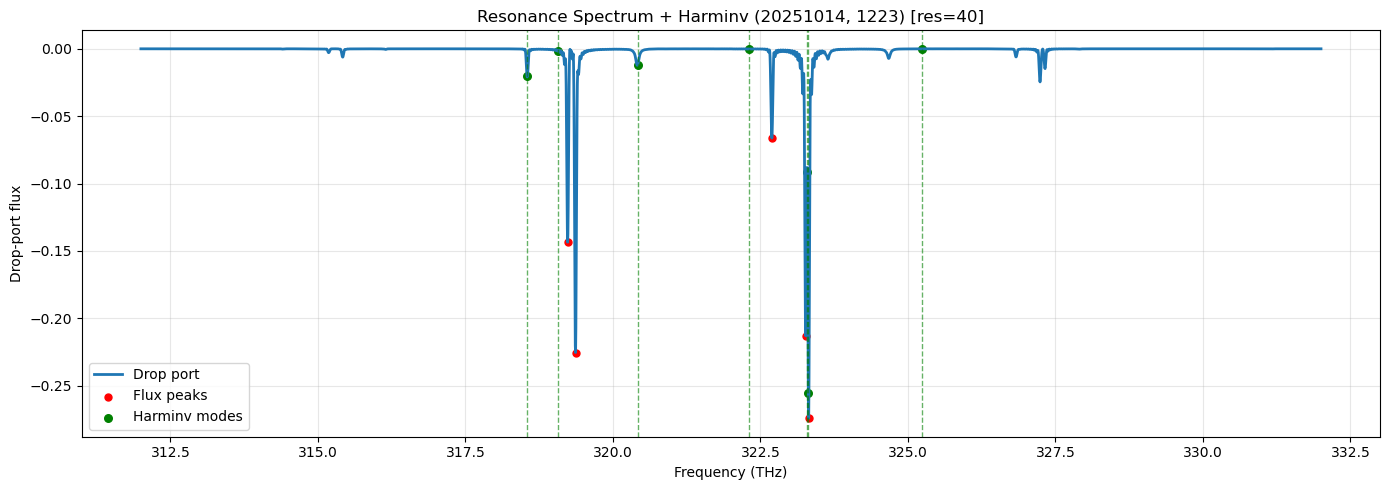


Resonances for 20251014_1223_sim_r3.5_g0.1_f322_res40_decay0.0001:
  Flux peaks (THz): [319.2318 319.3668 322.6927 323.2678 323.3178]
  Harminv modes (THz, Q):
    318.545 THz   Q = 34202.5
    319.068 THz   Q = 73210.7
    320.420 THz   Q = 5281.2
    322.310 THz   Q = 34235.5
    323.287 THz   Q = 21170.4
    323.311 THz   Q = 131262.1
    325.246 THz   Q = 33614.0


In [17]:

# ---------------------------------
# Helper: load flux data from HDF5
# ---------------------------------
def load_flux_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq = f["frequency"][:]       # Meep units (1/µm)
        flux_bus = f["flux_bus"][:]
        flux_drop = f["flux_drop"][:]
    return freq, flux_bus, flux_drop

# ---------------------------------
# Helper: load harminv data if available
# ---------------------------------
def load_harminv_data(h5_file):
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["freq_meep"][:]
        Q = f["Q"][:]
        decay = f["decay"][:]
    return freq_meep, Q, decay

# ---------------------------------
# Helper: parse parameters from folder name
# ---------------------------------
def parse_params_from_name(folder_name):
    pattern = (
        r"(?P<date>\d{8})_(?P<time>\d{4})_sim_r(?P<r>[\d\.]+)_g(?P<g>[\d\.]+)"
        r"_f(?P<f>[\d\.]+)_res(?P<res>\d+)_decay(?P<decay>[\deE\-\+\.]+)"
    )
    match = re.search(pattern, folder_name)
    return match.groupdict() if match else {}

# ---------------------------------
# Collect resonance data
# ---------------------------------
resonance_summary = []

# ---------------------------------
# Main loop: process and plot each dataset
# ---------------------------------
for folder in selected_folders:
    run_dir = os.path.join(base_dir, folder)
    flux_file = os.path.join(run_dir, "flux_data.h5")
    harminv_file = os.path.join(run_dir, "harminv_data.h5")

    if not os.path.exists(flux_file):
        print(f"No flux_data.h5 found in {run_dir}, skipping.")
        continue

    # --- Load flux data ---
    freq_meep, flux_bus, flux_drop = load_flux_data(flux_file)
    freq_thz = freq_meep * (c0 / um_scale) / 1e12

    # --- Find resonance peaks ---
    peaks, _ = find_peaks(-flux_drop, prominence=0.03)
    res_freqs = freq_thz[peaks]

    # --- Try to load Harminv data ---
    harminv_thz = []
    harminv_Q = []
    if os.path.exists(harminv_file):
        freq_meep_h, Q, decay = load_harminv_data(harminv_file)
        harminv_thz = freq_meep_h * (c0 / um_scale) / 1e12
        harminv_Q = Q
    else:
        print(f"No harminv_data.h5 found in {run_dir}.")

    # --- Parse parameters ---
    params = parse_params_from_name(folder)
    date = params.get("date", "unknown")
    time = params.get("time", "unknown")
    res = params.get("res", "?")

    # --- Plot each dataset ---
    plt.figure(figsize=(14, 5))
    plt.plot(freq_thz, flux_drop, lw=2, color="C0", label="Drop port")
    plt.scatter(res_freqs, flux_drop[peaks], color="red", s=25, label="Flux peaks")

    # --- Add Harminv resonances ---
    if len(harminv_thz) > 0:
        for f, q in zip(harminv_thz, harminv_Q):
            plt.axvline(f, color="green", ls="--", lw=1, alpha=0.6)
        plt.scatter(harminv_thz, np.interp(harminv_thz, freq_thz, flux_drop),
                    color="green", s=30, label="Harminv modes")

    # --- Labels and title ---
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Drop-port flux")
    plt.title(f"Resonance Spectrum + Harminv ({date}, {time}) [res={res}]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Print info ---
    print(f"\nResonances for {folder}:")
    print("  Flux peaks (THz):", np.round(res_freqs, 4))
    if len(harminv_thz) > 0:
        print("  Harminv modes (THz, Q):")
        for f, q in zip(harminv_thz, harminv_Q):
            print(f"    {f:.3f} THz   Q = {q:.1f}")


## For final_meep_sim output

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

def load_and_plot_flux_data(folder_name, base_dir="data", convert_to_thz=True):
    """
    Load and plot flux data from .npy files in the specified data subfolder.

    Parameters
    ----------
    folder_name : str
        Name of the subfolder inside 'data/' containing flux_bus.npy, flux_drop.npy, and freqs.npy
    base_dir : str, optional
        Base directory where data folders are stored (default: 'data')
    convert_to_thz : bool, optional
        Convert frequency axis from Meep units (1/µm) to THz (default: True)

    Returns
    -------
    freqs : np.ndarray
        Frequency array (THz if convert_to_thz=True)
    flux_bus : np.ndarray
        Flux data from the bus waveguide
    flux_drop : np.ndarray
        Flux data from the drop waveguide
    """
    # --- Paths ---
    folder_path = os.path.join(base_dir, folder_name)
    freq_file = os.path.join(folder_path, "freqs.npy")
    flux_bus_file = os.path.join(folder_path, "flux_bus.npy")
    flux_drop_file = os.path.join(folder_path, "flux_drop.npy")

    # --- Check existence ---
    for fpath in [freq_file, flux_bus_file, flux_drop_file]:
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing file: {fpath}")

    # --- Load data ---
    freqs = np.load(freq_file)
    flux_bus = np.load(flux_bus_file)
    flux_drop = np.load(flux_drop_file)

    # --- Convert to THz if requested ---
    if convert_to_thz:
        freqs = freqs * 299.792458  # Meep units (1/µm) → THz

    min_flux = np.min(flux_drop)
    min_freq = freqs[np.argmin(flux_drop)]
    print(f"Minimum flux at {min_freq:.4f} THz: {min_flux:.2e}")

    # --- Plot ---
    plt.figure(figsize=(15, 5))
    plt.plot(freqs, flux_drop, label="Drop port", lw=2)
    plt.xlabel("Frequency (THz)" if convert_to_thz else "Frequency (1/µm)")
    plt.ylabel("Flux")
    plt.title(f"Flux Spectrum – {folder_name}")
    plt.legend()
    plt.grid(True, ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return freqs, flux_bus, flux_drop


Minimum flux at 323.2913 THz: -1.08e-01


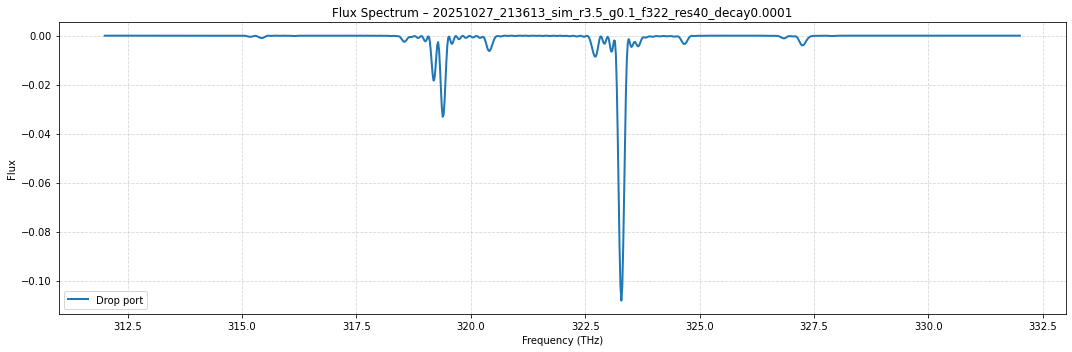

In [4]:
folder = "20251027_213613_sim_r3.5_g0.1_f322_res40_decay0.0001"
freqs, flux_bus, flux_drop = load_and_plot_flux_data(folder)

# optional: convert to THz if your Meep frequencies are in 1/µm
freqs_THz = freqs * 299.792458  # since 1/µm × c0 (µm/ps) = THz

20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005: Minimum flux at 317.7594 THz -> -4.59e+00


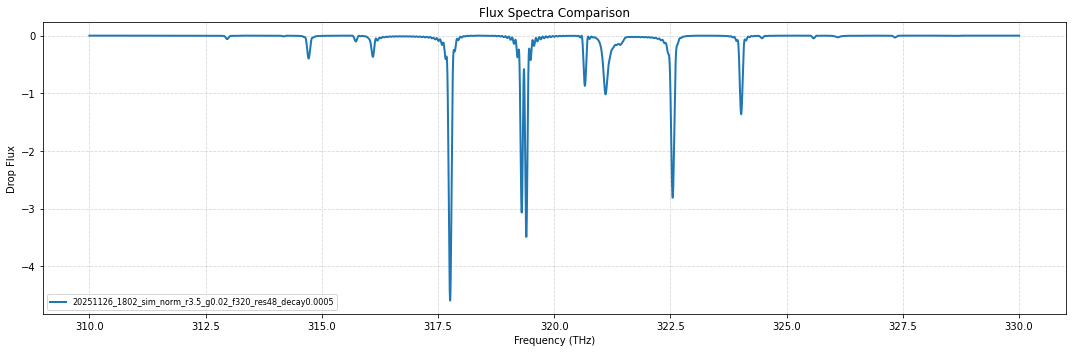

In [9]:
def load_flux_data_from_folder(folder_name, base_dir="data", convert_to_thz=True):
    """Load flux data from .npy files in one folder."""
    folder_path = os.path.join(base_dir, folder_name)
    freq_file = os.path.join(folder_path, "freqs_thz.npy")
    flux_bus_file = os.path.join(folder_path, "flux_bus.npy")
    flux_drop_file = os.path.join(folder_path, "flux_drop.npy")

    # --- Check existence ---
    for fpath in [freq_file, flux_bus_file, flux_drop_file]:
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing file: {fpath}")

    # --- Load ---
    freqs = np.load(freq_file)
    flux_bus = np.load(flux_bus_file)
    flux_drop = np.load(flux_drop_file)

    # --- Convert to THz if requested ---
    if convert_to_thz:
        freqs = freqs # 1/µm → THz

    return freqs, flux_bus, flux_drop


def plot_multiple_flux_data(folders, base_dir="data", convert_to_thz=True):
    """Plot multiple datasets (folders) on one shared frequency axis."""
    plt.figure(figsize=(15, 5))

    for folder in folders:
        freqs, flux_bus, flux_drop = load_flux_data_from_folder(folder, base_dir, convert_to_thz)
        min_flux = np.min(flux_drop)
        min_freq = freqs[np.argmin(flux_drop)]
        print(f"{folder}: Minimum flux at {min_freq:.4f} THz -> {min_flux:.2e}")

        plt.plot(freqs, flux_drop, lw=2, label=folder)

    plt.xlabel("Frequency (THz)" if convert_to_thz else "Frequency (1/µm)")
    plt.ylabel("Drop Flux")
    plt.title("Flux Spectra Comparison")
    plt.legend(fontsize=8)
    plt.grid(True, ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# ----------------------------
# Example usage
# ----------------------------
folders = [
    "20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005",
]

plot_multiple_flux_data(folders)

## CW sweep Data

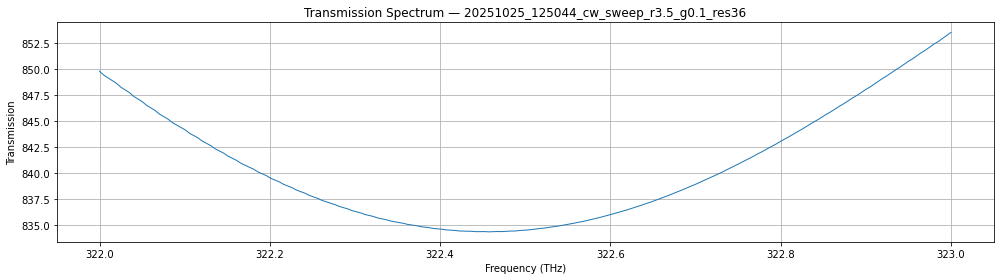

In [4]:

def plot_cw_data(folder_name, base_dir="data_cw"):
    """
    Load and plot continuous-wave transmission data.
    
    Parameters:
        folder_name (str): name of the simulation results folder (inside base_dir)
        base_dir (str): base directory where data is stored, default = "data_cw"
    """
    folder_path = os.path.join(base_dir, folder_name)
    
    # Check folder exists
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    # Load data files
    freqs_file = os.path.join(folder_path, "freqs_thz.npy")
    trans_file = os.path.join(folder_path, "transmission_raw.npy")

    freqs_thz = np.load(freqs_file)
    transmission = np.load(trans_file)

    # Normalize transmission (optional)
    trans_norm = transmission / np.max(transmission)

    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(freqs_thz, transmission, lw=1)
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Transmission")
    plt.title(f"Transmission Spectrum — {folder_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Example usage:
plot_cw_data("20251025_125044_cw_sweep_r3.5_g0.1_res36")


-----------
Initializing structure...
time for choose_chunkdivision = 0.00036394 s
Working in 2D dimensions.
Computational cell is 12 x 10.9167 x 0 with resolution 24
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (10.24,10.24,10.24)
     block, center = (0,3.71,0)
          size (12,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (10.24,10.24,10.24)


     block, center = (0,-3.71,0)
          size (12,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (10.24,10.24,10.24)
time for set_epsilon = 0.548165 s
-----------


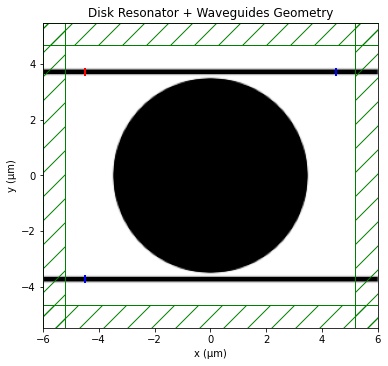

In [28]:
import math
import os

import meep as mp
import matplotlib.pyplot as plt
import numpy as np
import h5py
from datetime import datetime
import time

from mpi4py import MPI
import h5py

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

c0 = 299792458  # m/s
um_scale = 1e-6  # 1 µm in m

# -----------------------------
# Simulation parameters
# -----------------------------

# Materials
#gaas = mp.Medium(epsilon=np.square(3.2)) # not really gaas, just kept the name, now epsilon used from paper
#gaas = mp.Medium(epsilon=12, E_susceptibilities=[mp.LorentzianSusceptibility(frequency=0, gamma=0.5, sigma=1)])
sigma_meep = 0.000
n_eff = 3.2
gaas = mp.Medium(epsilon= n_eff**2, D_conductivity=2*math.pi*1*sigma_meep/n_eff)
#gaas = mp.Medium(epsilon=12)
air = mp.Medium(epsilon=1)

# Disk and waveguide geometry
disk_radius = 3.5
wg_length = 12
wg_width = 0.22
gap = 0.1  # distance between disk and waveguides

# Simulation cell size
cell_x = wg_length
cell_y = 2*(disk_radius + gap + wg_width/2) + 3.5
cell = mp.Vector3(cell_x, cell_y, 0)

# PML layers
pml_layers = [mp.PML(0.8)]

# -----------------------------
# Geometry: disk + two waveguides
# -----------------------------
geometry = [
    mp.Cylinder(radius=disk_radius, height=mp.inf, center=mp.Vector3(0,0), material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, disk_radius + gap + wg_width/2),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, -disk_radius - gap - wg_width/2),
             material=gaas)
]

geometry_norm = [
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, disk_radius + gap + wg_width/2),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, -disk_radius - gap - wg_width/2),
             material=gaas)
]


# -----------------------------
# Source (broadband run)
# -----------------------------
dist_src = 1.5
source_x = -wg_length/2 + dist_src
source_y = disk_radius + gap + wg_width/2

for f_thz in [190]:
    #f_thz = 320
    f_cen = f_thz * um_scale * 1e12 / c0  # convert to Meep freq (1/um)
    df_thz = 20  # n THz
    df = df_thz * um_scale * 1e12 / c0  # convert to Meep freq (1/um)
    field_decay = 1e-5  # field decay for stopping condition
    resolution = 24  # pixels/um
    nfreq = 20000  # single value



    # -----------------------------

    # -----------------------------
    # Main Simulation (disk + two waveguides)
    # -----------------------------
    geometry = [
        mp.Cylinder(radius=disk_radius, height=mp.inf, center=mp.Vector3(0,0), material=gaas),
        mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
                center=mp.Vector3(0, disk_radius + gap + wg_width/2),
                material=gaas),
        mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
                center=mp.Vector3(0, -disk_radius - gap - wg_width/2),
                material=gaas)
    ]

    sources = [mp.Source(mp.GaussianSource(frequency=f_cen, fwidth=df),
                        component=mp.Hz,
                        center=mp.Vector3(source_x, source_y),
                        size=mp.Vector3(0, wg_width, 0))]

    flux_region_bus = mp.FluxRegion(center=mp.Vector3(wg_length/2 - dist_src,
                                                    disk_radius + gap + wg_width/2),
                                    size=mp.Vector3(0, wg_width, 0))

    flux_region_drop = mp.FluxRegion(center=mp.Vector3(-wg_length/2 + dist_src,
                                                    -disk_radius - gap - wg_width/2),
                                    size=mp.Vector3(0, wg_width, 0))

    sim = mp.Simulation(cell_size=cell,
                        eps_averaging=True,
                        geometry=geometry,
                        sources=sources,
                        boundary_layers=pml_layers,
                        resolution=resolution)

    trans_flux_bus = sim.add_flux(f_cen, df, nfreq, flux_region_bus)
    trans_flux_drop = sim.add_flux(f_cen, df, nfreq, flux_region_drop)


 # -----------------------------
# Quick simulation to plot geometry only
# ----------------------------

fig, ax = plt.subplots(figsize=(6, 6))
sim.plot2D(ax=ax)
plt.title("Disk Resonator + Waveguides Geometry")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

